In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv("Churn_Modelling.csv")  # replace with your dataset

print(df.head())
print(df.info())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object', 'string']).columns

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")
    df[col] = le.fit_transform(df[col])

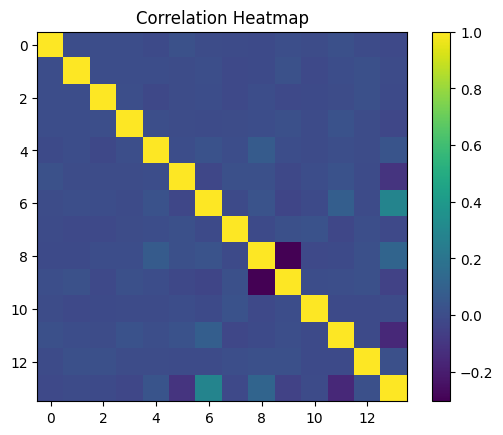

In [6]:
# Correlation heatmap
corr = df.corr()
plt.imshow(corr)
plt.title("Correlation Heatmap")
plt.colorbar()
plt.show()

In [9]:
# Drop irrelevant columns
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

# Define target
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [12]:
reg = LinearRegression()
reg.fit(X_train, y_train)
print("Regression R2:", reg.score(X_test, y_test))

Regression R2: 0.13999177774118443


In [13]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8155
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1607
           1       0.60      0.18      0.28       393

    accuracy                           0.82      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.82      0.77      2000



In [18]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8155
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1607
           1       0.60      0.18      0.28       393

    accuracy                           0.82      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.82      0.77      2000



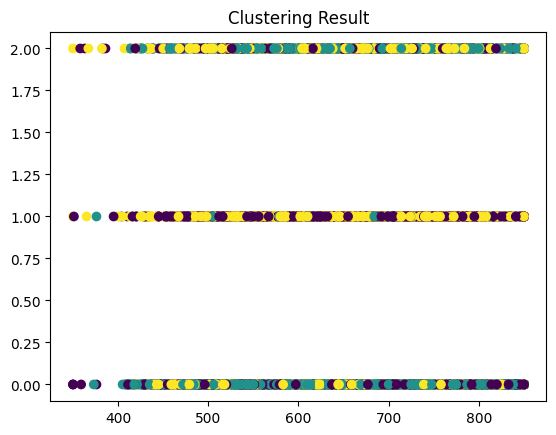

In [14]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

df["Cluster"] = kmeans.labels_

plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=df["Cluster"])
plt.title("Clustering Result")
plt.show()

In [17]:
from mlxtend.frequent_patterns import apriori, association_rules

df_assoc = df.copy()

# Create categories
df_assoc['AgeGroup'] = pd.cut(df_assoc['Age'], bins=3, labels=["Young", "Middle", "Old"])
df_assoc['BalanceLevel'] = pd.cut(df_assoc['Balance'], bins=3, labels=["Low", "Medium", "High"])
df_assoc['SalaryLevel'] = pd.cut(df_assoc['EstimatedSalary'], bins=3, labels=["Low", "Medium", "High"])

# Select columns
df_assoc = df_assoc[['AgeGroup', 'BalanceLevel', 'SalaryLevel', 'Exited']]

# One-hot encode
df_binary = pd.get_dummies(df_assoc)

# Apriori
frequent = apriori(df_binary, min_support=0.1, use_colnames=True)
rules = association_rules(frequent, metric="confidence", min_threshold=0.5)

print(rules.head())

                        antecedents                       consequents  \
0               frozenset({Exited})      frozenset({AgeGroup_Middle})   
1               frozenset({Exited})  frozenset({BalanceLevel_Medium})   
2     frozenset({BalanceLevel_Low})       frozenset({AgeGroup_Young})   
3  frozenset({BalanceLevel_Medium})       frozenset({AgeGroup_Young})   
4       frozenset({AgeGroup_Young})  frozenset({BalanceLevel_Medium})   

   antecedent support  consequent support  support  confidence      lift  \
0              0.2037              0.2702   0.1182    0.580265  2.147539   
1              0.2037              0.5262   0.1275    0.625920  1.189511   
2              0.4353              0.7106   0.3183    0.731220  1.029018   
3              0.5262              0.7106   0.3652    0.694033  0.976685   
4              0.7106              0.5262   0.3652    0.513932  0.976685   

   representativity  leverage  conviction  zhangs_metric   jaccard  certainty  \
0               1.0  0.

/home/mounisha16/myenv/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
